#  Perbanding metode machine learning untuk Analisis Sentimen IMDb Movie

Penelitian pada notebook ini membangun dan membandingkan model:
- Logistic Regression
- Support Vector Machine (SVM)
- Naive Bayes
- Stochastic Gradient Descent Classifier (SGD)
---
- **Usulan Akhir**: Support Vector Machine (SVM)

---
###  Alur Kerja
| Tahap | Deskripsi |
|---|---|
| 1 | Import Library |
| 2 | Load Data|
| 3 | Exploratory Data Analysis |
| 4 | Data Splitting |
| 5 | Tokenization dan Stopword |
| 6 | Text Preprocessing |
| 7 | Feature Extraction dengan Bag of Words |
| 8 | Feature Extraction dengan TF-IDF |
| 9 | Label Encoding|
| 10 | Metode Klasifikasi yang digunakan |
| 9 | Logistic Regression|
| 9 | Perbandingan Bag of Words dan TF-IDF|
| 9 | Support Vector Machinne (SVM)|
| 9 | Naive Bayes|
| 9 | Stochastic Gradient Descent (SGD) |
| 9 | Visualisasi Perbandingan Performa Model |
| 9 | Kesimpulan |

# Import Library

Pada tahap ini dilakukan inisialisasi beberapa library yang digunakan dalam proses analisis sentimen pada dataset IMDb. Library `pandas` dan `numpy` digunakan untuk manipulasi dan pengolahan data. Library `nltk`, `BeautifulSoup`, dan `re` digunakan pada tahap preprocessing teks seperti tokenisasi, penghapusan stopword, stemming, penghapusan HTML tag, dan karakter khusus.

Selanjutnya, `CountVectorizer` dan `TfidfVectorizer` digunakan untuk mengubah data teks menjadi representasi numerik agar dapat diproses oleh model machine learning. Model klasifikasi yang digunakan adalah `LogisticRegression` dari library `sklearn`. Selain itu, library `classification_report`, `confusion_matrix`, dan `accuracy_score` digunakan untuk mengevaluasi performa model klasifikasi.

Untuk visualisasi data dan hasil evaluasi, digunakan library `matplotlib` dan `seaborn`.


In [1]:
#Load the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelBinarizer
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize,sent_tokenize
from bs4 import BeautifulSoup
import re,string,unicodedata
from nltk.tokenize.toktok import ToktokTokenizer
from nltk.stem import WordNetLemmatizer
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score


# Load Dataset

Pada tahap ini dilakukan pembacaan dataset IMDb menggunakan fungsi `read_csv()` dari library `pandas`. Dataset yang telah dibaca kemudian disimpan ke dalam variabel `data` untuk digunakan pada proses analisis selanjutnya seperti preprocessing, pelatihan model, dan evaluasi.


In [3]:
data = pd.read_csv(
    "IMDB Dataset.csv",
    encoding='utf-8',
    engine='python',
    on_bad_lines='skip'
)

data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Exploratory Data Analysis (EDA)

Tahap Exploratory Data Analysis (EDA) dilakukan untuk memahami karakteristik dataset sebelum dilakukan proses pemodelan. Pada tahap ini dilakukan pengecekan jumlah data, deskripsi dataset, serta distribusi label sentimen positif dan negatif. Proses ini bertujuan untuk mengetahui kondisi data dan memastikan dataset berada dalam kondisi yang baik untuk digunakan pada proses klasifikasi.


In [4]:
print(data.shape)

(50000, 2)


In [5]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [6]:
data['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


# Data Splitting

Pada tahap ini dataset dibagi menjadi data training dan data testing menggunakan fungsi `train_test_split()` dari library `sklearn`. Data training digunakan untuk melatih model machine learning, sedangkan data testing digunakan untuk mengevaluasi performa model. Pembagian data dilakukan dengan rasio 80:20 agar model dapat belajar dari sebagian besar data dan tetap memiliki data uji untuk proses evaluasi.


In [7]:
from sklearn.model_selection import train_test_split

X = data['review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Tokenization dan Stopword

Pada tahap ini dilakukan inisialisasi tokenizer dan stopword bahasa Inggris menggunakan library `nltk`. Tokenizer digunakan untuk memecah teks menjadi token atau kata-kata, sedangkan stopword digunakan untuk menghapus kata-kata umum yang tidak memiliki pengaruh besar terhadap analisis sentimen, seperti “the”, “is”, dan “and”.


In [9]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [10]:
#Tokenization of text
tokenizer=ToktokTokenizer()
#Setting English stopwords
stopword_list=nltk.corpus.stopwords.words('english')

# Text Preprocessing

Tahap preprocessing dilakukan untuk membersihkan data teks agar lebih terstruktur dan mudah diproses oleh model machine learning. Proses preprocessing meliputi penghapusan tag HTML, penghapusan karakter khusus, stemming untuk mengubah kata menjadi bentuk dasar, serta penghapusan stopword. Seluruh tahapan preprocessing digabungkan ke dalam satu fungsi agar proses pengolahan data menjadi lebih efisien dan terstruktur.


In [11]:
# preprocessing function
def preprocessing(text):

    # remove html
    soup = BeautifulSoup(text, "html.parser")
    text = soup.get_text()

    # remove square brackets
    text = re.sub('\[[^]]*\]', '', text)

    # remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # stemming
    ps = PorterStemmer()
    text = ' '.join([ps.stem(word) for word in text.split()])

    # remove stopwords
    tokens = tokenizer.tokenize(text)
    tokens = [token.strip() for token in tokens]

    filtered_tokens = [
        token for token in tokens
        if token.lower() not in stopword_list
    ]

    text = ' '.join(filtered_tokens)

    return text

<>:9: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\['
/tmp/ipykernel_4193/3564084069.py:9: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[[^]]*\]', '', text)


# Preprocessing Data Train dan Test

Pada tahap ini fungsi preprocessing diterapkan pada data training dan data testing. Tujuannya adalah untuk membersihkan seluruh teks ulasan sebelum dilakukan proses ekstraksi fitur menggunakan metode vectorization.


In [12]:
X_train = X_train.apply(preprocessing)
X_test = X_test.apply(preprocessing)

# Feature Extraction dengan Bag of Words

Pada tahap ini digunakan metode Bag of Words (BoW) menggunakan `CountVectorizer` untuk mengubah data teks menjadi representasi numerik berdasarkan frekuensi kemunculan kata. Hasil vectorization ini akan digunakan sebagai input pada model machine learning.


In [13]:
#Count vectorizer for bag of words
cv = CountVectorizer(
    min_df=1,
    max_df=0.95,
    binary=False,
    ngram_range=(1,2)
)

# transformed train reviews
cv_train_reviews = cv.fit_transform(X_train)

# transformed test reviews
cv_test_reviews = cv.transform(X_test)

print('BOW_cv_train:', cv_train_reviews.shape)
print('BOW_cv_test:', cv_test_reviews.shape)

BOW_cv_train: (40000, 2491477)
BOW_cv_test: (10000, 2491477)


# Feature Extraction dengan TF-IDF

Pada tahap ini digunakan metode TF-IDF (Term Frequency-Inverse Document Frequency) menggunakan `TfidfVectorizer` untuk memberikan bobot pada kata berdasarkan tingkat kepentingannya dalam dokumen. Metode ini membantu model dalam mengenali kata-kata yang lebih relevan terhadap sentimen positif maupun negatif.


In [14]:
#Tfidf vectorizer
tv = TfidfVectorizer(
    min_df=1,
    max_df=0.95,
    use_idf=True,
    ngram_range=(1,2)
)

# transformed train reviews
tv_train_reviews = tv.fit_transform(X_train)

# transformed test reviews
tv_test_reviews = tv.transform(X_test)

print('Tfidf_train:', tv_train_reviews.shape)
print('Tfidf_test:', tv_test_reviews.shape)

Tfidf_train: (40000, 2491477)
Tfidf_test: (10000, 2491477)


# Label Encoding

Pada tahap ini dilakukan proses konversi label sentimen dari bentuk kategorikal menjadi numerik. Label “positive” diubah menjadi nilai 1 dan label “negative” diubah menjadi nilai 0 agar dapat diproses oleh algoritma machine learning.


In [16]:
y_train = y_train.map({
    'positive':1,
    'negative':0
})

y_test = y_test.map({
    'positive':1,
    'negative':0
})

Logistic Regression

# Metode Klasifikasi yang Digunakan

Pada penelitian ini dilakukan perbandingan beberapa algoritma machine learning untuk analisis sentimen, yaitu Logistic Regression, Support Vector Machine (SVM), Naive Bayes, dan Stochastic Gradient Descent (SGD). Setiap metode memiliki karakteristik dan performa yang berbeda dalam mengklasifikasikan sentimen ulasan film.




## Logistic Regression
### Training dan Evaluasi Logistic Regression

Logistic Regression merupakan algoritma klasifikasi linear yang bekerja dengan memprediksi probabilitas suatu data termasuk ke dalam kelas tertentu. Metode ini cukup populer dalam analisis sentimen karena mampu bekerja dengan baik pada data teks hasil ekstraksi TF-IDF maupun Bag of Words. Logistic Regression memiliki proses training yang cepat dan menghasilkan performa yang stabil.

In [17]:
#training the model
lr=LogisticRegression(penalty='l2',max_iter=500,C=1,random_state=42)
#Fitting the model for Bag of words
lr_bow=lr.fit(cv_train_reviews,y_train)
print(lr_bow)
#Fitting the model for tfidf features
lr_tfidf=lr.fit(tv_train_reviews,y_train)
print(lr_tfidf)

LogisticRegression(C=1, max_iter=500, random_state=42)
LogisticRegression(C=1, max_iter=500, random_state=42)


In [18]:
#Predicting the model for bag of words
lr_bow_predict=lr.predict(cv_test_reviews)
print(lr_bow_predict)
##Predicting the model for tfidf features
lr_tfidf_predict=lr.predict(tv_test_reviews)
print(lr_tfidf_predict)

[0 1 0 ... 1 0 1]
[0 1 0 ... 1 0 1]


### Perbandingan Bag of Words dan TF-IDF pada Logistic Regression

Pada penelitian ini digunakan dua metode ekstraksi fitur, yaitu Bag of Words (BoW) dan TF-IDF (Term Frequency-Inverse Document Frequency) untuk proses klasifikasi menggunakan algoritma Logistic Regression.

Bag of Words bekerja dengan merepresentasikan teks berdasarkan frekuensi kemunculan kata dalam dokumen tanpa memperhatikan tingkat kepentingan kata tersebut. Metode ini cukup baik dalam merepresentasikan data teks, namun masih memberikan bobot yang sama terhadap seluruh kata sehingga kata-kata umum dapat mempengaruhi performa model.

Sedangkan TF-IDF memberikan bobot yang lebih besar pada kata-kata penting dan mengurangi pengaruh kata yang sering muncul pada banyak dokumen. Dengan demikian, model dapat lebih fokus pada kata-kata yang memiliki hubungan kuat terhadap sentimen positif maupun negatif.

Berdasarkan hasil pengujian, Logistic Regression dengan TF-IDF menghasilkan performa yang lebih baik dibandingkan Bag of Words. Hal ini ditunjukkan dari nilai akurasi TF-IDF sebesar 89%, sedangkan Bag of Words memperoleh akurasi sebesar 86%. Hasil tersebut menunjukkan bahwa TF-IDF lebih efektif dalam merepresentasikan fitur teks pada proses analisis sentimen.


In [19]:
#Classification report for bag of words
lr_bow_report=classification_report(y_test,lr_bow_predict,target_names=['Negative','Positive'])
print(lr_bow_report)

#Classification report for tfidf features
lr_tfidf_report=classification_report(y_test,lr_tfidf_predict,target_names=['Negative','Positive'])
print(lr_tfidf_report)



              precision    recall  f1-score   support

    Negative       0.84      0.88      0.86      4961
    Positive       0.88      0.84      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000

              precision    recall  f1-score   support

    Negative       0.90      0.87      0.89      4961
    Positive       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [20]:
print("Accuracy BOW:",
      accuracy_score(y_test, lr_bow_predict))

print("Accuracy TFIDF:",
      accuracy_score(y_test, lr_tfidf_predict))

Accuracy BOW: 0.8609
Accuracy TFIDF: 0.8891


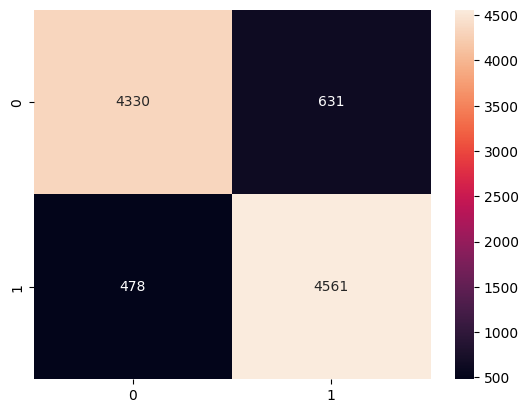

In [21]:
cm = confusion_matrix(y_test, lr_tfidf_predict)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Support Vector Machine (SVM)

### Training dan Evaluasi Support Vector Machine (SVM)
Support Vector Machine (SVM) merupakan algoritma klasifikasi yang bekerja dengan mencari hyperplane terbaik untuk memisahkan dua kelas data. SVM sangat cocok digunakan pada data teks karena mampu menangani data berdimensi tinggi dan sparse matrix yang dihasilkan dari proses vectorization.

Berdasarkan hasil pengujian, metode SVM memberikan performa terbaik dibandingkan metode lainnya dengan tingkat akurasi mencapai 91%. Hal ini menunjukkan bahwa SVM mampu mengklasifikasikan sentimen positif dan negatif dengan lebih optimal pada dataset IMDb.


In [23]:
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

# training
svm.fit(tv_train_reviews, y_train)

# prediction
svm_pred = svm.predict(tv_test_reviews)

# evaluation
print(classification_report(
    y_test,
    svm_pred,
    target_names=['Negative','Positive']
))

              precision    recall  f1-score   support

    Negative       0.92      0.89      0.91      4961
    Positive       0.90      0.92      0.91      5039

    accuracy                           0.91     10000
   macro avg       0.91      0.91      0.91     10000
weighted avg       0.91      0.91      0.91     10000



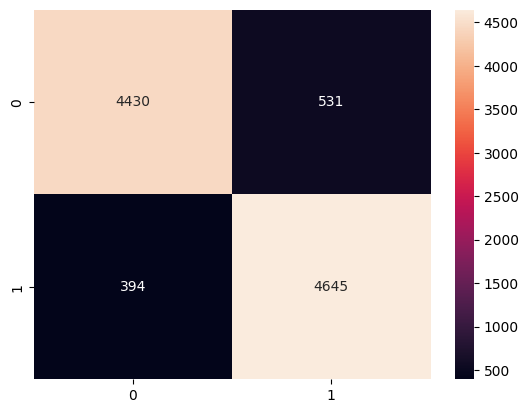

In [28]:
cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Naive Bayes

### Training dan Evaluasi Naive Bayes

Naive Bayes merupakan algoritma probabilistik yang bekerja berdasarkan Teorema Bayes dengan asumsi bahwa setiap fitur bersifat independen. Metode ini memiliki keunggulan dalam kecepatan proses training dan efisiensi komputasi sehingga sering digunakan pada klasifikasi teks. Namun, performanya biasanya sedikit lebih rendah dibandingkan SVM dan Logistic Regression karena asumsi independensi antar fitur.


In [24]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

# training
nb.fit(tv_train_reviews, y_train)

# prediction
nb_pred = nb.predict(tv_test_reviews)

# evaluation
print(classification_report(
    y_test,
    nb_pred,
    target_names=['Negative','Positive']
))

              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89      4961
    Positive       0.90      0.87      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



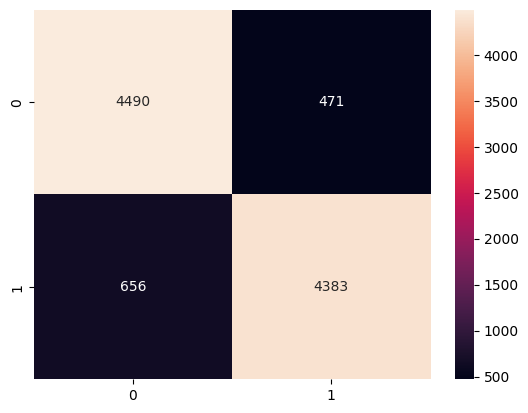

In [29]:
cm = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Stochastic Gradient Descent (SGD)

### Training dan Evaluasi Stochastic Gradient Descent (SGD)

Stochastic Gradient Descent (SGD) merupakan metode optimasi yang digunakan untuk melatih model linear secara iteratif. SGD bekerja dengan memperbarui parameter model berdasarkan sebagian kecil data secara bertahap sehingga proses training menjadi lebih cepat pada dataset berukuran besar. Pada analisis sentimen, SGD mampu menghasilkan performa yang cukup baik dengan waktu komputasi yang lebih efisien.

In [25]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=42)

# training
sgd.fit(tv_train_reviews, y_train)

# prediction
sgd_pred = sgd.predict(tv_test_reviews)

# evaluation
print(classification_report(
    y_test,
    sgd_pred,
    target_names=['Negative','Positive']
))

              precision    recall  f1-score   support

    Negative       0.91      0.87      0.89      4961
    Positive       0.88      0.91      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



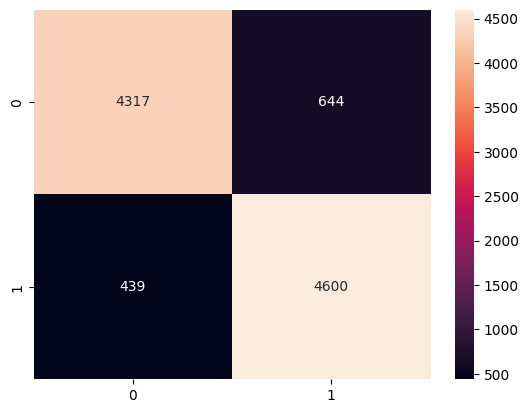

In [30]:
cm = confusion_matrix(y_test, sgd_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# Visualisasi Perbandingan Performa Model

Pada tahap ini dilakukan visualisasi menggunakan diagram batang (bar chart) untuk membandingkan performa beberapa algoritma machine learning yang digunakan dalam analisis sentimen, yaitu Logistic Regression, Support Vector Machine (SVM), Naive Bayes, dan Stochastic Gradient Descent (SGD).

Visualisasi ini bertujuan untuk mempermudah proses analisis dan interpretasi hasil akurasi dari masing-masing metode klasifikasi. Dengan menggunakan diagram batang, perbedaan performa antar model dapat terlihat dengan lebih jelas dan mudah dipahami.

Berdasarkan hasil visualisasi, metode Support Vector Machine (SVM) menunjukkan performa terbaik dengan tingkat akurasi sebesar 91%, diikuti oleh Logistic Regression dengan akurasi 89%, SGD sebesar 88%, dan Naive Bayes sebesar 88%. Hasil tersebut menunjukkan bahwa SVM lebih unggul dalam mengklasifikasikan sentimen positif dan negatif pada dataset IMDb karena mampu menangani data teks berdimensi tinggi secara lebih optimal.


In [31]:
models = pd.DataFrame({
    'Model': [
        'Logistic Regression (TFIDF)',
        'Linear SVC',
        'Multinomial Naive Bayes',
        'SGD Classifier'
    ],
    'Accuracy': [
        accuracy_score(y_test, lr_tfidf_predict),
        accuracy_score(y_test, svm_pred),
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, sgd_pred)
    ]
})

models.sort_values(by='Accuracy', ascending=False)

,Model,Accuracy
1,Linear SVC,0.9075
3,SGD Classifier,0.8917
0,Logistic Regression (TFIDF),0.8891
2,Multinomial Naive Bayes,0.8873


/tmp/ipykernel_4193/692464760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Accuracy', data=models.sort_values(by='Accuracy', ascending=False), palette='viridis')


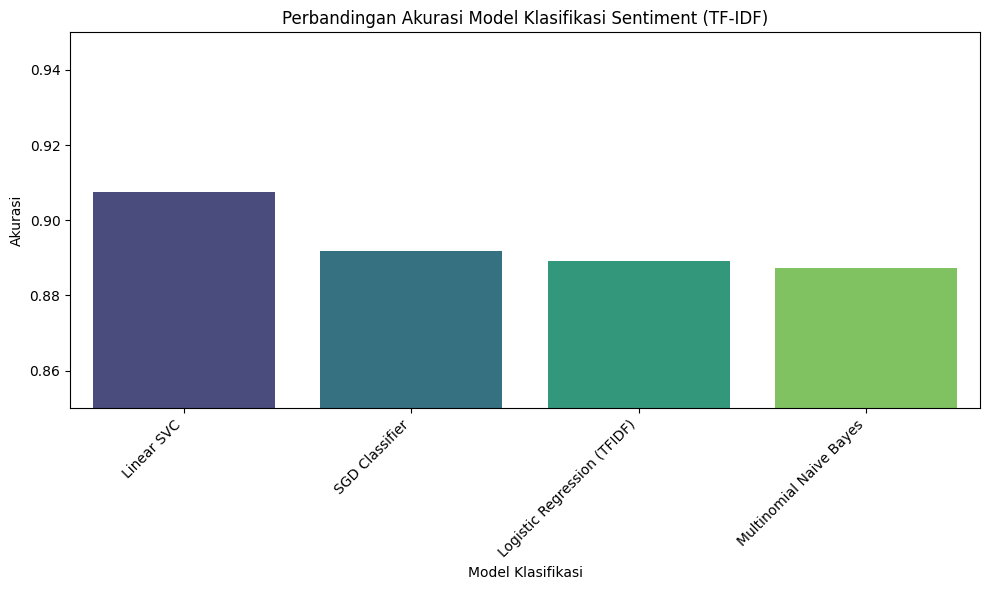

In [32]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Accuracy', data=models.sort_values(by='Accuracy', ascending=False), palette='viridis')
plt.title('Perbandingan Akurasi Model Klasifikasi Sentiment (TF-IDF)')
plt.xlabel('Model Klasifikasi')
plt.ylabel('Akurasi')
plt.ylim(0.85, 0.95) # Set y-axis limit to better visualize differences
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Kesimpulan

Berdasarkan hasil pengujian yang telah dilakukan, metode ekstraksi fitur TF-IDF menunjukkan performa yang lebih baik dibandingkan Bag of Words (BoW), khususnya pada algoritma Logistic Regression. Hal ini ditunjukkan dari nilai akurasi Logistic Regression dengan TF-IDF sebesar 89%, sedangkan penggunaan Bag of Words hanya menghasilkan akurasi sebesar 86%.

TF-IDF mampu memberikan bobot yang lebih baik terhadap kata-kata penting dalam dokumen sehingga representasi fitur teks menjadi lebih optimal untuk proses klasifikasi sentimen. Oleh karena itu, pada tahap pengujian selanjutnya seluruh algoritma machine learning menggunakan metode TF-IDF sebagai teknik ekstraksi fitur.

Berdasarkan perbandingan beberapa algoritma klasifikasi yang digunakan, yaitu Logistic Regression, Support Vector Machine (SVM), Naive Bayes, dan Stochastic Gradient Descent (SGD), metode Support Vector Machine (SVM) menghasilkan performa terbaik dengan tingkat akurasi sebesar 91%. Hasil tersebut menunjukkan bahwa SVM lebih unggul dalam menangani data teks berdimensi tinggi dan sparse matrix yang dihasilkan dari proses TF-IDF, sehingga mampu mengklasifikasikan sentimen positif dan negatif dengan lebih optimal pada dataset IMDb.


**THE END**